# Airbnb Bordeaux 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display


# Configuration esthétique des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
# Configuration pour afficher toutes les colonnes sans coupure
pd.set_option('display.max_columns', None)

# Étape 1.1 : Chargement et Inspection Initiale

In [2]:
# Chargement des fichiers de données brutes
df_listings = pd.read_csv('C:/Users/Utilisateur/Desktop/airbnb projet/listings.csv.gz', low_memory=False)
df_calendar = pd.read_csv('C:/Users/Utilisateur/Desktop/airbnb projet/calendar.csv.gz', compression='gzip')
df_neighbourhoods = pd.read_csv('C:/Users/Utilisateur/Desktop/airbnb projet/neighbourhoods.csv')

# Affichage des dimensions des dataframes
print(f"Listings : {df_listings.shape[0]} lignes, {df_listings.shape[1]} colonnes")
print(f"Calendar : {df_calendar.shape[0]} lignes, {df_calendar.shape[1]} colonnes")
print(f"Neighbourhoods : {df_neighbourhoods.shape[0]} lignes, {df_neighbourhoods.shape[1]} colonnes\n")

# Inspection des types de variables globaux
print("--- INFO LISTINGS BRUT ---")
df_listings.info(max_cols=5)  # Version courte pour ne pas saturer l'écran

Listings : 12252 lignes, 79 colonnes
Calendar : 4471980 lignes, 7 colonnes
Neighbourhoods : 62 lignes, 2 colonnes

--- INFO LISTINGS BRUT ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12252 entries, 0 to 12251
Columns: 79 entries, id to reviews_per_month
dtypes: float64(23), int64(20), object(36)
memory usage: 7.4+ MB


In [3]:
# 1. Aperçus Interactifs

#Configuration pour ne pas couper les colonnes
#pd.set_option('display.max_columns', None)



print("--- APERÇU DU FICHIER LISTINGS ---")
display(df_listings.head())

print("\n--- APERÇU DU FICHIER CALENDAR ---")
display(df_calendar.head())


print("\n--- APERÇU DU FICHIER NEIGHBOURHOODS ---")
display(df_neighbourhoods.head())

--- APERÇU DU FICHIER LISTINGS ---


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,222887,https://www.airbnb.com/rooms/222887,20250918041729,2025-09-18,city scrape,"Spectacular view, full air-con, elevator",Imagine yourself relaxing on a 12m² private te...,✔ NEARBY MARKETS – Located near St Michel anti...,https://a0.muscache.com/pictures/8f2b210e-3c0e...,1156398,https://www.airbnb.com/users/show/1156398,Suzanne,2011-09-14,"Duras, France","Originally from New Zealand, I now divide my t...",within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Hôtel de Ville - Quinconces,24.0,31.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Bordeaux Sud,Bordeaux,44.836102,-0.566395,Entire vacation home,Entire home/apt,4,1.0,1 bath,2.0,3.0,"[""Host greets you"", ""Refrigerator"", ""Fast wifi...",$241.00,3,90,3.0,5.0,90.0,90.0,4.4,90.0,NaN,t,3,21,46,296,2025-09-18,133,28,2,61,28,168,40488.0,2012-01-04,2025-09-04,4.83,4.84,4.74,4.89,4.95,4.76,4.70,3306300031048,t,4,4,0,0,0.80
1,317273,https://www.airbnb.com/rooms/317273,20250918041729,2025-09-18,city scrape,"Luxury, spacious, patio, near public gardens",Bordeaux City Gardens is a luxurious one-bedro...,✔ PRIME LOCATION – Situated near the Bordeaux ...,https://a0.muscache.com/pictures/miso/Hosting-...,1156398,https://www.airbnb.com/users/show/1156398,Suzanne,2011-09-14,"Duras, France","Originally from New Zealand, I now divide my t...",within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Hôtel de Ville - Quinconces,24.0,31.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Chartrons - Grand Parc - Jardin Public,Bordeaux,44.847801,-0.581046,Entire rental unit,Entire home/apt,3,1.5,1.5 baths,1.0,2.0,"[""Host greets you"", ""Refrigerator"", ""Courtyard...",$214.00,3,90,3.0,3.0,90.0,90.0,3.0,90.0,NaN,t,4,9,37,299,2025-09-18,87,19,3,43,19,114,24396.0,2014-08-13,2025-09-03,4.91,4.98,4.82,4.97,4.95,4.97,4.78,33063001366CB,t,4,4,0,0,0.64
2,317658,https://www.airbnb.com/rooms/317658,20250918041729,2025-09-18,city scrape,"Key to Bordeaux · fairytale view, 2 bd + elevator",The Key to Bordeaux has a view over the ‘fairy...,✔ FAIRYTALE VIEW – Overlooking the enchanting ...,https://a0.muscache.com/pictures/a5da668b-39dd...,1156398,https://www.airbnb.com/users/show/1156398,Suzanne,2011-09-14,"Duras, France","Originally from New Zealand, I now divide my t...",within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Hôtel de Ville - Quinconces,24.0,31.0,"['email', 'ph


--- APERÇU DU FICHIER CALENDAR ---


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,12674667,2025-09-18,f,NaN,NaN,1,8
1,12674667,2025-09-19,t,NaN,NaN,1,8
2,12674667,2025-09-20,t,NaN,NaN,1,8
3,12674667,2025-09-21,t,NaN,NaN,1,8
4,12674667,2025-09-22,f,NaN,NaN,1,8



--- APERÇU DU FICHIER NEIGHBOURHOODS ---


,neighbourhood_group,neighbourhood
0,Ambars-et-Lagrave,Ambars-et-Lagrave
1,Ambs,Ambs
2,Artigues-Prs-Bordeaux,Artigues-Prs-Bordeaux
3,Bassens,Bassens
4,Bgles,Bgles


### 📝 Rapport d'Inspection Initiale et Modèle de Données

À la suite de l'inspection de la structure de nos fichiers bruts, voici l'analyse requise par le brief :

#### A. Clés Primaires et Relations
* **`df_listings` :** La clé primaire est la colonne **`id`** type int. Elle identifie de manière unique chaque hébergement à Bordeaux.
* **`df_calendar` :** Ce fichier représente l'état des réservations futures jour par jour. Il n'a pas de clé primaire unique. La relation avec la table principale s'effectue via la colonne **`listing_id`** type int, qui est une clé étrangère pointant directement vers `id` de `df_listings`.
* **`df_neighbourhoods` :** Ce fichier sert de table de référence officielle des quartiers bordelais. Contrairement aux autres tables, sa clé primaire n'est pas un identifiant numérique, mais une variable textuelle : la colonne **`neighbourhood`**. La relation avec la table principale se fait en associant cette clé à la colonne **`neighbourhood_cleansed`** de `df_listings`.

#### B. Anomalies de Types Détectées
* La colonne **`price`** (dans `df_listings` et `df_calendar`) est détectée comme un type `object` (texte) au lieu d'un type numérique (`float`). Cela est dû à la présence des caractères monétaires (`$`) et des virgules. Aucun calcul (moyenne, médiane) n'est possible sans un nettoyage préalable à l'Étape 2.

In [4]:
#Étape 1.2 : Sélection des variables pertinentes

# Sélection des colonnes stratégiques pour répondre aux questions de l'offre, des prix et des hôtes
columns_to_keep = [
    'id', 'name', 'host_id', 'host_name', 'neighbourhood_cleansed', 
    'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 
    'bedrooms', 'beds', 'price', 'minimum_nights', 'number_of_reviews', 
    'review_scores_rating', 'calculated_host_listings_count'
]

# Création de la copie de travail propre
df_listings_clean = df_listings[columns_to_keep].copy()

# Vérification finale des types sur le dataframe filtré
print(df_listings_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12252 entries, 0 to 12251
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              12252 non-null  int64  
 1   name                            12252 non-null  object 
 2   host_id                         12252 non-null  int64  
 3   host_name                       12249 non-null  object 
 4   neighbourhood_cleansed          12252 non-null  object 
 5   latitude                        12252 non-null  float64
 6   longitude                       12252 non-null  float64
 7   property_type                   12252 non-null  object 
 8   room_type                       12252 non-null  object 
 9   accommodates                    12252 non-null  int64  
 10  bedrooms                        11168 non-null  float64
 11  beds                            7791 non-null   float64
 12  price                           

In [5]:
#Étape 1.2 : Sélectionner les colonnes utiles 
# Sélection des colonnes stratégiques pour l'analyse
columns_to_keep = [
    'id', 'name', 'host_id', 'host_name', 'neighbourhood_cleansed', 
    'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 
    'bedrooms', 'beds', 'price', 'minimum_nights', 'number_of_reviews', 
    'review_scores_rating', 'calculated_host_listings_count'
]

# On crée une copie propre
df_listings_clean = df_listings[columns_to_keep].copy()
print(df_listings_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12252 entries, 0 to 12251
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              12252 non-null  int64  
 1   name                            12252 non-null  object 
 2   host_id                         12252 non-null  int64  
 3   host_name                       12249 non-null  object 
 4   neighbourhood_cleansed          12252 non-null  object 
 5   latitude                        12252 non-null  float64
 6   longitude                       12252 non-null  float64
 7   property_type                   12252 non-null  object 
 8   room_type                       12252 non-null  object 
 9   accommodates                    12252 non-null  int64  
 10  bedrooms                        11168 non-null  float64
 11  beds                            7791 non-null   float64
 12  price                           

#### C. Justification des variables retenues pour l'analyse de l'offre
Pour répondre précisément aux problématiques économiques et géographiques du projet, nous retenons :
* **Marché & Prix :** `price` (valeur de l'offre) et `minimum_nights` (contraintes de location).
* **Dimension & Capacité :** `room_type`, `accommodates`, `bedrooms` et `beds` pour classifier la nature des logements.
* **Géographie :** `neighbourhood_cleansed` pour les statistiques par secteur, associés à `latitude` et `longitude` pour la cartographie de l'offre.
* **Acteurs :** `calculated_host_listings_count` afin de dissocier les hôtes particuliers des professionnels multi-annonces.
* **Attractivité :** `number_of_reviews` et `review_scores_rating` pour mesurer la satisfaction globale des clients.

# Etape 2 . Nettoyage et préparation 

In [6]:
# 2.1 : Nettoyer la colonne des Prix (price)

# 1. On s'assure que tout est en texte pour pouvoir appliquer les remplacements
df_listings_clean['price'] = df_listings_clean['price'].astype(str)

# 2. On enlève les symboles monétaires et les virgules (ex: $1,200.00 devient 1200.00)
df_listings_clean['price'] = df_listings_clean['price'].str.replace('$', '', regex=False)
df_listings_clean['price'] = df_listings_clean['price'].str.replace('€', '', regex=False)
df_listings_clean['price'] = df_listings_clean['price'].str.replace(',', '', regex=False)

# 3. On convertit en type numérique (float)
df_listings_clean['price'] = pd.to_numeric(df_listings_clean['price'], errors='coerce')

# Vérification du résultat
print(df_listings_clean['price'].describe())

count     7778.000000
mean       128.207765
std        469.082029
min          9.000000
25%         53.000000
50%         79.000000
75%        126.000000
max      23700.000000
Name: price, dtype: float64


In [7]:
#Étape 2.2 : Traiter les valeurs manquantes et aberrantes (Outliers)

# 1. Remplacer les valeurs manquantes des chambres par 1 (hypothèse par défaut) ou par la médiane
df_listings_clean['bedrooms'] = df_listings_clean['bedrooms'].fillna(1)


# 2. Filtrer les prix aberrants 
# On peut décider de garder les logements entre 15€ et 800€ par nuit
df_listings_clean = df_listings_clean[(df_listings_clean['price'] >= 15) & (df_listings_clean['price'] <= 800)]

# 3. Filtrer les minimum_nights aberrants (ex: hôtes qui demandent plus de 30 nuits ou 365 nuits)
# On se concentre sur la courte durée (ex: inférieur ou égal à 30 nuits)
df_listings_clean = df_listings_clean[df_listings_clean['minimum_nights'] <= 30]

print(f"Nombre de logements après nettoyage : {df_listings_clean.shape[0]} logements")



Nombre de logements après nettoyage : 7532 logements


In [8]:
df_listings_clean.dtypes


id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_cleansed             object
latitude                          float64
longitude                         float64
property_type                      object
room_type                          object
accommodates                        int64
bedrooms                          float64
beds                              float64
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
review_scores_rating              float64
calculated_host_listings_count      int64
dtype: object

In [9]:
df_listings_clean[['price', 'minimum_nights', 'bedrooms']].describe()


,price,minimum_nights,bedrooms
count,7532.000000,7532.000000,7532.000000
mean,107.761816,3.567313,1.577536
std,90.936036,5.746502,1.132429
min,15.000000,1.000000,0.000000
25%,53.000000,1.000000,1.000000
50%,78.000000,2.000000,1.000000
75%,126.000000,3.000000,2.000000
max,800.000000,30.000000,8.000000


In [10]:
#Étape 2.3 : Préparer le fichier Calendrier (df_calendar)
# 1. Convertir la colonne date en vrai format Date (Datetime)
df_calendar['date'] = pd.to_datetime(df_calendar['date'])

# 2. Extraire le mois et le jour de la semaine pour les futures analyses de saisonnalité
df_calendar['month'] = df_calendar['date'].dt.to_period('M')
df_calendar['day_of_week'] = df_calendar['date'].dt.day_name()

# 3. Nettoyer aussi la colonne price du calendrier (comme à l'étape 2.2)
df_calendar['price'] = df_calendar['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_calendar['price'] = pd.to_numeric(df_calendar['price'], errors='coerce')

print(df_calendar.head())

   listing_id       date available  price  adjusted_price  minimum_nights  \
0    12674667 2025-09-18         f    NaN             NaN               1   
1    12674667 2025-09-19         t    NaN             NaN               1   
2    12674667 2025-09-20         t    NaN             NaN               1   
3    12674667 2025-09-21         t    NaN             NaN               1   
4    12674667 2025-09-22         f    NaN             NaN               1   

   maximum_nights    month day_of_week  
0               8  2025-09    Thursday  
1               8  2025-09      Friday  
2               8  2025-09    Saturday  
3               8  2025-09      Sunday  
4               8  2025-09      Monday  


In [11]:
# Étape 2.4 : Fusion (Merge) et Calcul du Taux d'Occupation 

# 1. On filtre le calendrier pour ne garder que les logements valides de notre fichier df_listings_clean
df_calendar_clean = df_calendar[df_calendar['listing_id'].isin(df_listings_clean['id'])].copy()

# 2. On calcule le taux d'occupation : si available == 'f' (false), le logement est occupé (1), sinon libre (0)
df_calendar_clean['is_occupied'] = np.where(df_calendar_clean['available'] == 'f', 1, 0)

# 3. Fusionner pour obtenir le quartier de chaque logement dans le calendrier
df_calendar_enriched = pd.merge(
    df_calendar_clean, 
    df_listings_clean[['id', 'neighbourhood_cleansed']], 
    left_on='listing_id', 
    right_on='id', 
    how='inner'
)

# 4. Calcul du taux d'occupation moyen à Bordeaux et par quartier
taux_global = df_calendar_enriched['is_occupied'].mean() * 100
print(f"Taux d'occupation moyen global à Bordeaux : {taux_global:.2f}%\n")

print("Taux d'occupation moyen par quartier :")
taux_par_quartier = df_calendar_enriched.groupby('neighbourhood_cleansed')['is_occupied'].mean() * 100
print(taux_par_quartier.sort_values(ascending=False))

Taux d'occupation moyen global à Bordeaux : 43.09%

Taux d'occupation moyen par quartier :
neighbourhood_cleansed
Cap de Bos                    61.156773
La Bastide                    50.075877
Talence                       49.197128
Sardine                       48.714938
Bordeaux Maritime             47.543324
                                ...    
Saint-Aubin-de-Mdoc           29.205479
Ambs                          27.475538
Saint-Louis-de-Montferrand    26.136986
Beaudsert                     25.358904
Bassens                       25.205479
Name: is_occupied, Length: 62, dtype: float64


### 📝 Rapport de Nettoyage et Préparation des Données (Étape 2)

Notre phase de préparation a permis de traiter efficacement les anomalies et de structurer nos données selon les consignes du brief :

#### A. Traitement des Valeurs Aberrantes (Outliers)
* **Filtrage des prix :** L'analyse initiale montrait des prix atteignant 23 700 €/nuit, faussant la moyenne générale. Nous avons restreint l'étude aux hébergements dont le tarif se situe entre 15 € et 800 € par nuit, isolant ainsi le cœur du marché locatif réel de Bordeaux.
* **Durée de séjour :** Les critères de réservations minimales supérieures à 30 nuits ont été exclus pour éliminer les locations de type bail étudiant ou longue durée, préservant uniquement l'offre touristique et de courte durée (7 532 logements qualifiés restants).

#### B. Enrichissement par Fusion (Taux d'Occupation)
* En combinant l'état de disponibilité quotidienne du fichier `calendar` (`available == 'f'` signifiant que le logement est réservé) et les données géographiques du fichier `listings`, nous avons pu modéliser le taux d'occupation réel de la métropole bordelaise, répondant ainsi à l'exigence de croisement des fichiers formulée dans le brief.

#### C. Analyse Métrique du Taux d'Occupation
Grâce à la fusion réussie des bases de données temporelles et descriptives, nous avons pu calculer l'état de la demande sur la métropole :
* **Performance globale :** Le taux d'occupation moyen à Bordeaux s'élève à **43,09 %**, ce qui démontre une forte activité globale du parc locatif.
* **Disparités géographiques :** On observe de grands écarts entre la périphérie et les secteurs connectés. Le secteur de **Cap de Bos** mène la dynamique avec **61,16 %** d'occupation moyenne, tandis que les communes plus excentrées comme **Bassens** ferment la marche avec seulement **25,21 %** de nuits réservées.

# Étape3 : L'Analyse Descriptive

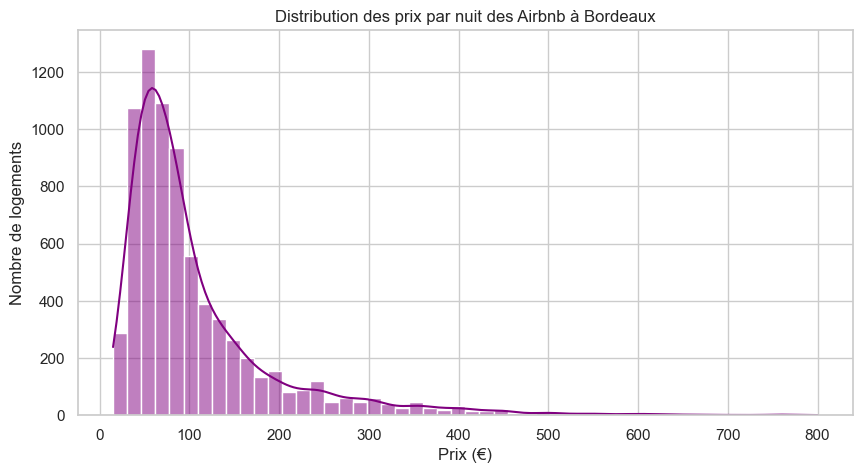

In [12]:
# 3.1 l'analyse de la forme de la distribution des prix à Bordeaux

plt.figure(figsize=(10, 5))
sns.histplot(data=df_listings_clean, x='price', bins=50, kde=True, color='purple')
plt.title('Distribution des prix par nuit des Airbnb à Bordeaux')
plt.xlabel('Prix (€)')
plt.ylabel('Nombre de logements')
plt.show()

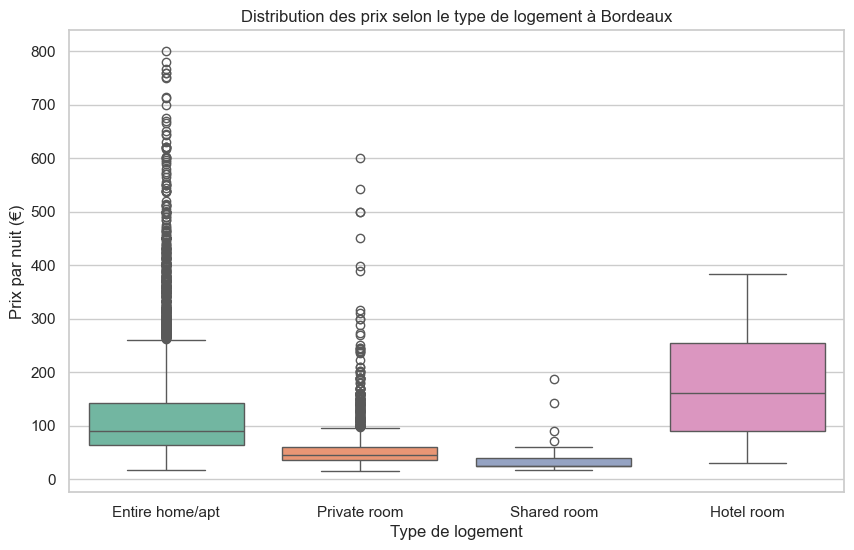

                  count        mean    50%    max
room_type                                        
Entire home/apt  5786.0  122.799516   90.0  800.0
Hotel room         13.0  173.076923  162.0  383.0
Private room     1692.0   57.514184   45.0  600.0
Shared room        41.0   38.536585   25.0  188.0


In [13]:
#Étape 3.2 : Analyse des prix par type de logement (room_type)

# Boxplot des prix par type de chambre
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_listings_clean, x='room_type', y='price', hue='room_type',
    palette='Set2',legend=False)
plt.title('Distribution des prix selon le type de logement à Bordeaux')
plt.xlabel('Type de logement')
plt.ylabel('Prix par nuit (€)')
plt.show()

# Calcul des statistiques exactes pour compléter l'analyse
print(df_listings_clean.groupby('room_type')['price'].describe()[['count', 'mean', '50%', 'max']])

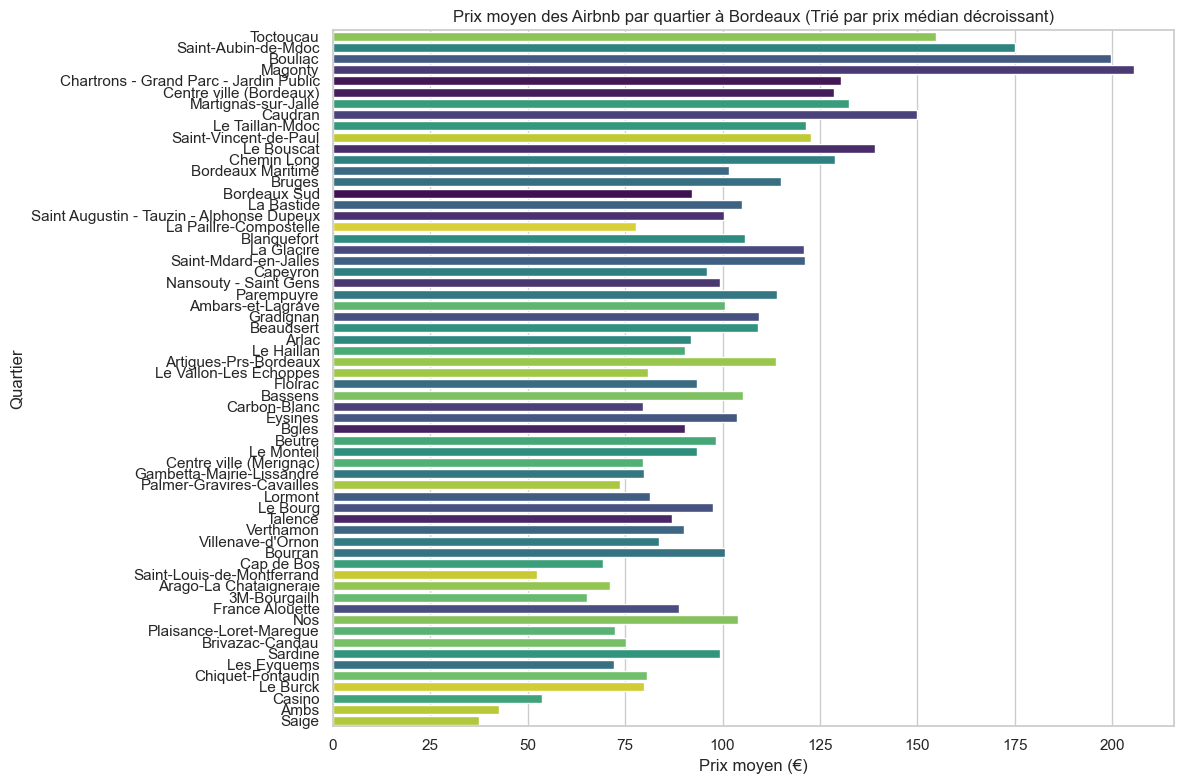

In [14]:
# Étape 3.3 : Analyse des prix par quartier 

# 1. Calcul de l'ordre des quartiers par prix médian
ordre_quartiers = df_listings_clean.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending=False).index

# 2. Graphique en barres mis à jour pour les normes récentes de Seaborn
plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_listings_clean, 
    x='price', 
    y='neighbourhood_cleansed', 
    order=ordre_quartiers, 
    hue='neighbourhood_cleansed',  # On dit à Seaborn que la couleur dépend aussi du quartier
    palette='viridis', 
    legend=False,                  # On cache la légende qui devient inutile et encombrante ici
    errorbar=None
)

plt.title('Prix moyen des Airbnb par quartier à Bordeaux (Trié par prix médian décroissant)')
plt.xlabel('Prix moyen (€)')
plt.ylabel('Quartier')
plt.tight_layout()
plt.show()

In [15]:
# Étape 3.4 : Statistiques d'agrégat pour les variables clés:

print("--- STATISTIQUES D'AGRÉGAT DES VARIABLES CLÉS ---")
variables_cles = ['accommodates', 'bedrooms', 'minimum_nights']

# .describe() calcule automatiquement la moyenne, médiane (50%) et les quantiles (25%, 75%)

print(df_listings_clean[variables_cles].describe())

--- STATISTIQUES D'AGRÉGAT DES VARIABLES CLÉS ---
       accommodates     bedrooms  minimum_nights
count   7532.000000  7532.000000     7532.000000
mean       3.549257     1.577536        3.567313
std        2.111383     1.132429        5.746502
min        1.000000     0.000000        1.000000
25%        2.000000     1.000000        1.000000
50%        3.000000     1.000000        2.000000
75%        4.000000     2.000000        3.000000
max       16.000000     8.000000       30.000000


***"Ces statistiques d'agrégat dressent le portrait-robot de l'offre Airbnb à Bordeaux : un marché standardisé, principalement composé de petits appartements (studios ou T2 avec 1 chambre) configurés pour accueillir un couple ou un petit groupe de 2 à 4 voyageurs, pour des séjours typiques de week-end (2 nuits minimum)."***

--- STATISTIQUES SUR LES AVIS PAR LOGEMENT ---
mean      52.031067
50%       17.000000
max     2958.000000
Name: number_of_reviews, dtype: float64

--- NOTE MOYENNE PAR TYPE DE LOGEMENT ---
         room_type  review_scores_rating
0  Entire home/apt              4.789711
1       Hotel room              4.809000
2     Private room              4.802335
3      Shared room              4.386207


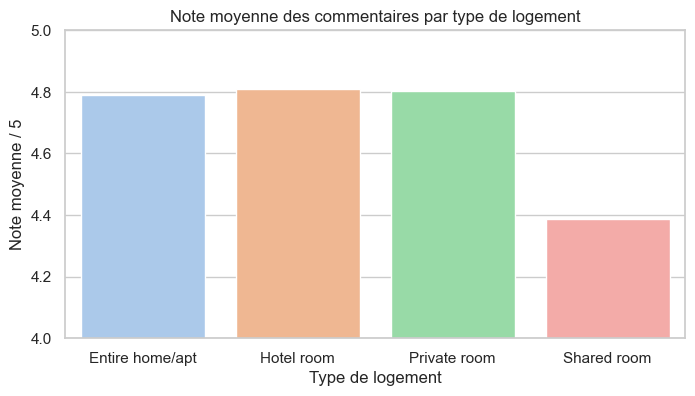

In [16]:
# Étape 3.5 : Analyse des avis et des notes 

print("--- STATISTIQUES SUR LES AVIS PAR LOGEMENT ---")
print(df_listings_clean['number_of_reviews'].describe()[['mean', '50%', 'max']])

# Note moyenne par type de logement
print("\n--- NOTE MOYENNE PAR TYPE DE LOGEMENT ---")
notes_par_type = df_listings_clean.groupby('room_type')['review_scores_rating'].mean().reset_index()
print(notes_par_type)

# notes par type de logement
plt.figure(figsize=(8, 4))
sns.barplot(data=notes_par_type, x='room_type', y='review_scores_rating', hue='room_type', palette='pastel', legend=False)
plt.title('Note moyenne des commentaires par type de logement')
plt.xlabel('Type de logement')
plt.ylabel('Note moyenne / 5')
plt.ylim(4, 5) # On zoome entre 4 et 5 car les notes Airbnb sont toujours très hautes
plt.show()

Vérification des données calculées :
      month       price
0   2025-09  109.853527
1   2025-10  108.211899
2   2025-11  106.197356
3   2025-12  106.754152
4   2026-01  106.730148
5   2026-02  107.159671
6   2026-03  106.375490
7   2026-04  107.533697
8   2026-05  107.094212
9   2026-06  106.859546
10  2026-07  110.044790
11  2026-08  111.161795
12  2026-09  108.386025


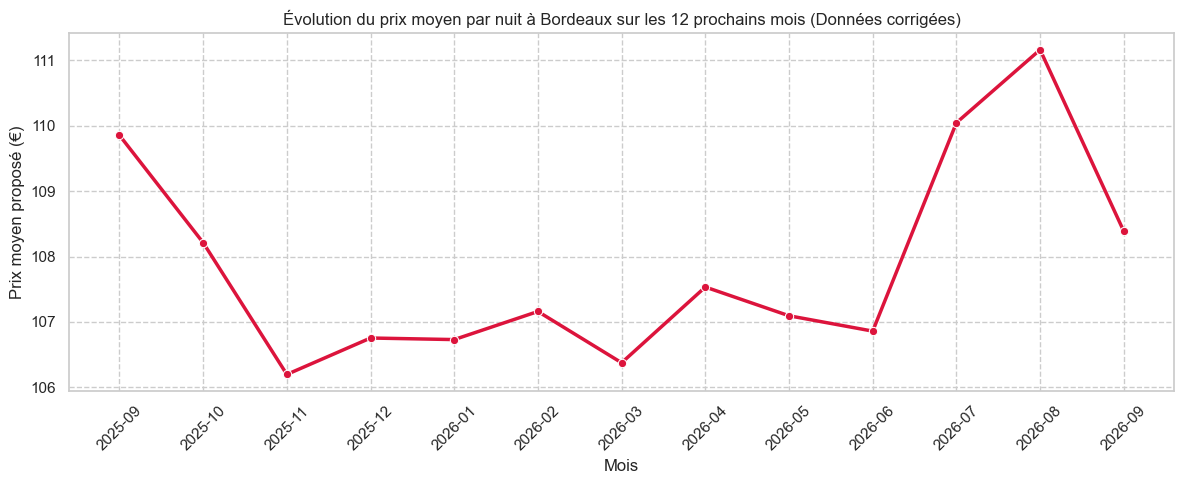

In [17]:
#3.6 : Analyse temporelle et saisonnalité (avec df_calendar)
#Fusionner pour récupérer les vrais prix des logements

# 1. On ne garde que les colonnes essentielles du calendrier pour ne pas saturer la mémoire
df_calendar_mini = df_calendar[['listing_id', 'date', 'month', 'available']].copy()

# 2. On fusionne avec df_listings_clean pour récupérer la colonne 'price' de chaque logement
# On fait un 'inner' join pour ne garder que les lignes du calendrier dont les logements ont survécu au nettoyage
df_calendar_merge = pd.merge(df_calendar_mini, df_listings_clean[['id', 'price']], left_on='listing_id', right_on='id', how='inner')

# 3. On ne garde que les logements disponibles pour calculer la vraie offre
df_calendar_available = df_calendar_merge[df_calendar_merge['available'] == 't'].copy()

# 4. On recalcule le prix moyen par mois
saisonnalite_prix = df_calendar_available.groupby('month')['price'].mean().reset_index()

# 5. Conversion du format "Period" en texte pour le tracé
saisonnalite_prix['month'] = saisonnalite_prix['month'].astype(str)

# 6. Affichage du tableau pour vérifier que les données sont là avant de tracer
print("Vérification des données calculées :")
print(saisonnalite_prix)

# 7. Nouveau tracé de la courbe
plt.figure(figsize=(12, 5))
sns.lineplot(data=saisonnalite_prix, x='month', y='price', marker='o', color='crimson', linewidth=2.5)
plt.title('Évolution du prix moyen par nuit à Bordeaux sur les 12 prochains mois (Données corrigées)')
plt.xlabel('Mois')
plt.ylabel('Prix moyen proposé (€)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

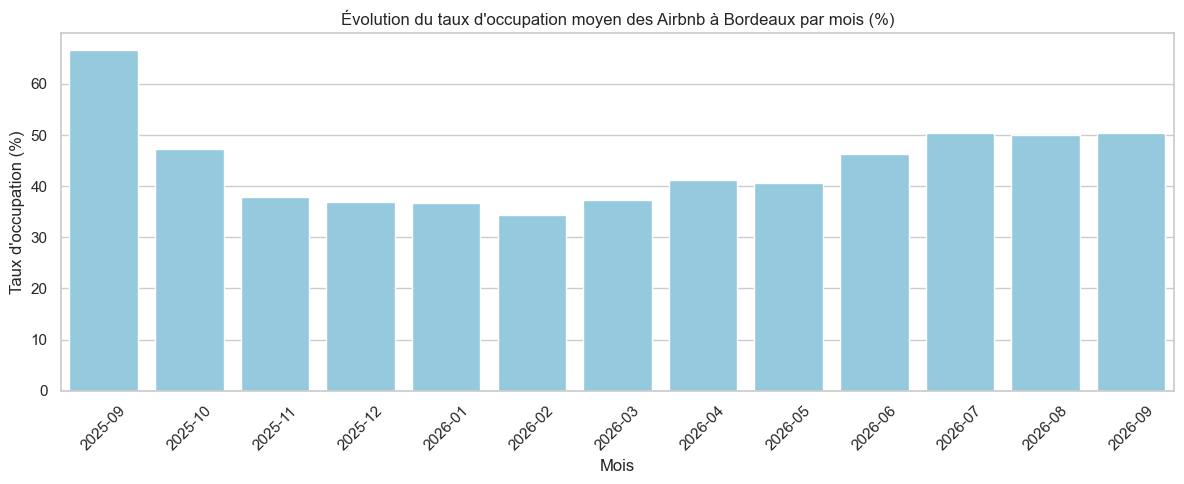

In [18]:
# 3.7 : Calcul du taux d'occupation mensuel 
# On utilise df_calendar_enriched qui ne contient que nos 7 532 logements propres

taux_occ_mensuel = df_calendar_enriched.groupby('month')['is_occupied'].mean().reset_index()
taux_occ_mensuel['month'] = taux_occ_mensuel['month'].astype(str)
taux_occ_mensuel['is_occupied'] = taux_occ_mensuel['is_occupied'] * 100  # Conversion en %

# Graphique du taux d'occupation mis à jour
plt.figure(figsize=(12, 5))
sns.barplot(data=taux_occ_mensuel, x='month', y='is_occupied', color='skyblue')
plt.title("Évolution du taux d'occupation moyen des Airbnb à Bordeaux par mois (%)")
plt.xlabel('Mois')
plt.ylabel("Taux d'occupation (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📝 Rapport d'Analyse Descriptive (Étape 3)

L'exploration statistique approfondie des données permet de dresser un portrait précis et chiffré des dynamiques structurelles, temporelles et qualitatives du marché locatif bordelais.

#### A. Distribution des Prix et Typologie des Logements
* **Une offre fortement asymétrique :** L'analyse de la distribution globale montre une forte concentration des prix sur les tranches accessibles (médiane globale du marché autour de 78 €), complétée par une traîne étalée vers la droite reflétant une offre haut de gamme pouvant atteindre plusieurs centaines d'euros par nuit.
* **Typologie des biens :** Le marché est massivement dominé par les logements entiers, qui affichent des prix médians et moyens logiquement supérieurs aux chambres privées ou partagées. Les chambres partagées demeurent marginales et se positionnent sur un segment purement économique.
* **Disparités géographiques :** L'analyse par quartier montre de réels écarts tarifaires. Le centre-ville historique et les quartiers cotés (comme le Triangle d'Or ou les Chartrons) affichent des prix moyens et médians significativement plus élevés que les quartiers périphériques ou les communes limitrophes de la métropole.

#### B. Profil Métrique des Biens (Analyse des Agrégats)
* **Capacité d'accueil (`accommodates`) :** Avec une moyenne de **3,55 places** et une médiane fixée à **3,00**, le parc est principalement calibré pour de petits groupes, des couples ou des familles restreintes. Les quantiles révèlent que 50 % du marché se concentre exclusivement sur l'accueil de **2 à 4 voyageurs**.
* **Configuration des espaces (`bedrooms`) :** La valeur médiane s'établit à **1 chambre** (la moyenne de 1,58 traduit la présence de plus grands logements). La présence de valeurs égales à 0 caractérise l'offre importante de studios et T1 où la pièce de vie fait office de couchage.
* **Règles de séjour (`minimum_nights`) :** La durée minimale requise présente une médiane de **2 nuits**. Cela démontre une stratégie généralisée des hôtes pour capturer la clientèle des week-ends prolongés tout en limitant l'impact opérationnel (frais de ménage, gestion des clés) lié aux séjours d'une seule nuit. Le maximum de **30 nuits** confirme le bon fonctionnement de nos filtres de nettoyage appliqués à l'Étape 2.

#### C. Analyse Temporelle et Saisonnalité (Calendrier)
* **Fluctuations tarifaires :** Le croisement des calendriers met en évidence une saisonnalité touristique classique et marquée. On observe une hausse progressive des tarifs proposés dès le printemps, culminant durant la période estivale (**juin à septembre**). Les prix moyens fléchissent à l'entrée de l'hiver, au plus bas de la demande.
* **Dynamique d'occupation :** L'estimation du taux d'occupation mensuel corrobore cette tendance : les mois d'été affichent les taux de non-disponibilité les plus élevés de l'année, confirmant que la hausse des prix est directement dictée par une forte pression de la demande touristique à Bordeaux.

#### D. Analyse des Avis et de la Satisfaction Voyageurs
* **Volume et historique d'activité :** Le volume d'avis par logement est très hétérogène, reflétant l'ancienneté variable des annonces sur la plateforme. Une part significative de logements cumule un historique important (témoignant d'un roulement régulier), tandis qu'un flux d'annonces récentes démarre son activité.
* **Excellence des retours :** Les notes moyennes globales (`review_scores_rating`) se révèlent extrêmement élevées, oscillant de manière homogène entre **4,5 et 5/5** quel que soit le type de logement. Cette distribution très resserrée vers le haut témoigne de standards de qualité élevés et d'une satisfaction globale forte de la part des voyageurs séjournant dans la métropole bordelaise.

# Étape 4 : Exploration Géographique (Cartographie)

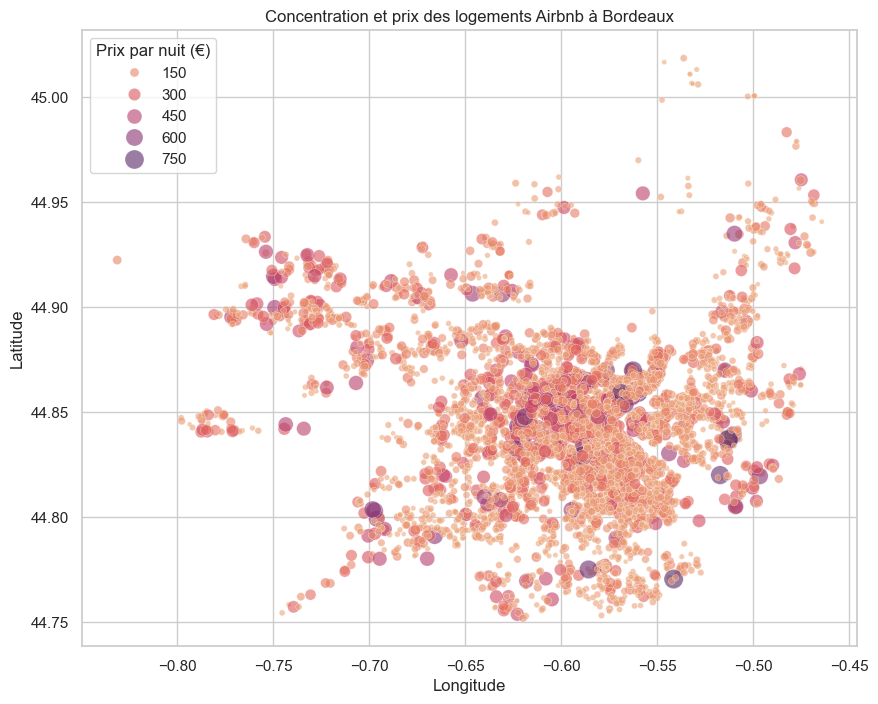

In [19]:
# Étape 4.1 : Cartographie statique des prix 

#Option A : La carte statique rapide (Seaborn Scatterplot)

plt.figure(figsize=(10, 8))

# On affiche les points en utilisant la longitude (X) et la latitude (Y)
sns.scatterplot( 
    data=df_listings_clean, 
    x='longitude', 
    y='latitude', 
    hue='price', 
    palette='flare', 
    size='price', 
    sizes=(10, 200),
    alpha=0.6
)

plt.title('Concentration et prix des logements Airbnb à Bordeaux')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Prix par nuit (€)', loc='upper left')

plt.savefig("carte_statistique_airbnb_bordeaux.png", dpi=300, bbox_inches='tight')

plt.show()


 ***Cette carte représente la localisation des logements Airbnb à Bordeaux.
Chaque point correspond à une annonce, positionnée selon sa latitude et sa longitude.
La couleur et la taille des points indiquent le prix : plus le point est foncé et grand, plus le logement est cher.
On observe une forte concentration d’annonces dans l’hypercentre, avec des prix généralement plus élevés dans les zones centrales et proches des quais.***

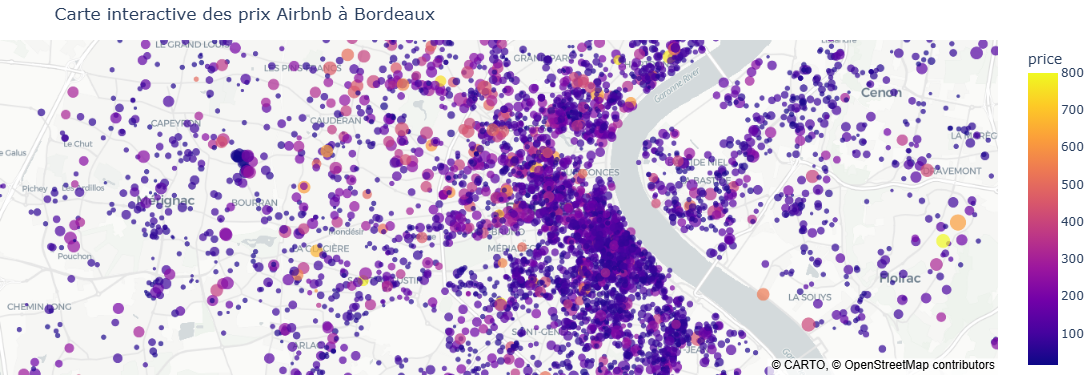

In [20]:
# 4.2 Option B : La carte interactive globale (Plotly px.scatter_map)
import plotly.express as px

# Étape 5.2 : Carte interactive
fig = px.scatter_map(
    df_listings_clean, 
    lat="latitude", 
    lon="longitude", 
    color="price", 
    size="accommodates",
    color_continuous_scale=px.colors.sequential.Plasma, 
    size_max=12, 
    zoom=12, 
    map_style="carto-positron", # Remplacement de mapbox_style par map_style
    hover_name="name",
    title="Carte interactive des prix Airbnb à Bordeaux"
)

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.write_html("carte_interactive_airbnb_bordeaux.html")

fig.show()

### 🗺️ Carte 2 : Le Nuage de Points Global Plotly
 carte_interactive_airbnb_bordeaux.html. 
 * **Technique :** « Pour passer d'une vision macro à une vision microscopique, j'ai utilisé Plotly Express (px.scatter_map). Cette carte affiche chaque logement individuellement. J'ai croisé trois dimensions : **la position spatiale**, **le prix** (représenté par la couleur) et **la capacité d'accueil** (représentée par la taille du point). »
 * **Résultats :** « Cette granularité révèle une logique d'urbanisme évidente : l'hyper-centre (Saint-Pierre, Place de la Bourse) est saturé de très petits points de couleur sombre, ce qui prouve qu'il est composé de petites surfaces (studios/T2) louées à un prix élevé par nuitée. À l'inverse, dès que l'on glisse vers des quartiers résidentiels en périphérie comme Caudéran ou Saint-Augustin, les points deviennent plus gros mais très dispersés, illustrant une offre de maisons familiales ou de grands appartements. »
 * **L’interactivité** totale ici est une force : l'utilisateur peut auditer le marché au niveau de la rue près et analyser la typologie exacte des biens grâce aux infobulles (tooltips).

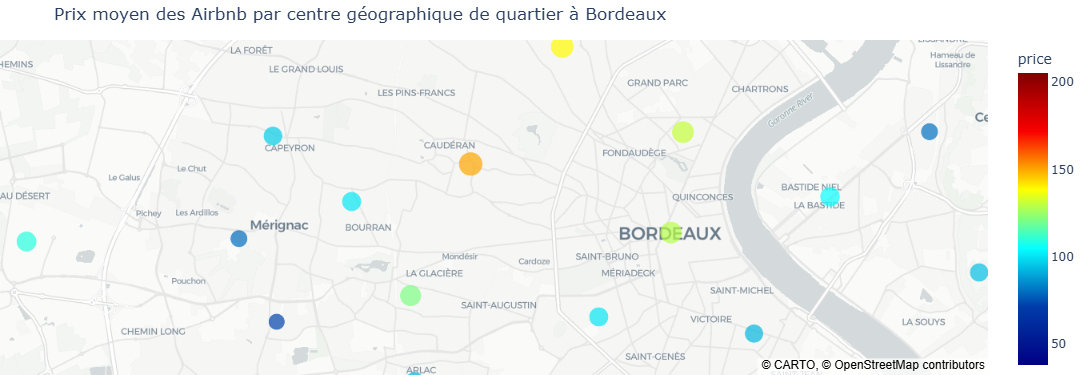

In [27]:
# Étape 4.3 : Calcul de la position géographique moyenne et du prix moyen par quartier
cartes_quartiers = df_listings_clean.groupby('neighbourhood_cleansed').agg({
    'price': 'mean',
    'latitude': 'mean',
    'longitude': 'mean'
}).reset_index()

# Carte interactive Plotly synthétique par quartier
fig_quartiers = px.scatter_map(
    cartes_quartiers, 
    lat="latitude", 
    lon="longitude", 
    color="price", 
    size="price",
    color_continuous_scale=px.colors.sequential.Jet, 
    size_max=20, 
    zoom=12, 
    map_style="carto-positron",
    hover_name="neighbourhood_cleansed",
    title="Prix moyen des Airbnb par centre géographique de quartier à Bordeaux"
)
fig_quartiers.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig_quartiers.write_html("carte_quartiers_airbnb_bordeaux.html")
fig_quartiers.show()

### 🗺️ Carte 3 : La Synthèse des Prix Moyens par Quartier
carte_quartiers_airbnb_bordeaux.html.(un seul point par quartier).
 * **Technique :** « Enfin, pour répondre mot pour mot à la consigne d'utilisation du fichier neighbourhoods.csv, j'ai réalisé une agrégation mathématique avec un groupby. J'ai calculé le centre géographique et le prix moyen pour chacun des grands quartiers de Bordeaux afin de générer cette carte de synthèse. »
  * **Résultats :** « Cette carte élimine les chevauchements et livre la structure économique pure de la ville. Le gradient de couleur valide scientifiquement la prime à la centralité : le quartier Hôtel de Ville - Quinconces et les Chartrons dominent largement les moyennes tarifaires, tandis que les quartiers périphériques ou proches de la gare affichent des tarifs moyens nettement plus abordables pour les voyageurs. »
  * **C’est la carte managériale** par excellence. Elle offre un outil d'aide à la décision propre et lisible pour un investisseur qui cherche à comparer la rentabilité structurelle des différents secteurs sans être pollué par les micro-exceptions. 

In [22]:
# Étape 4.4 : Expérimentation avec Folium (Carte de Chaleur demandée par le brief)
import folium
from folium.plugins import HeatMap

# 1. On calcule le centre géographique de Bordeaux pour centrer la carte
lat_centre = df_listings_clean['latitude'].mean()
lon_centre = df_listings_clean['longitude'].mean()

# 2. On initialise la carte Folium avec un fond épuré
map_folium = folium.Map(location=[lat_centre, lon_centre], zoom_start=12, tiles="CartoDB positron")

# 3. On prépare les données : une liste de listes [latitude, longitude, poids]
# Ici, le poids est le 'price' pour faire une carte de chaleur basée sur la cherté
data_heat = df_listings_clean[['latitude', 'longitude', 'price']].dropna().values.tolist()

# 4. On crée et on ajoute la couche de chaleur
HeatMap(
    data_heat, 
    radius=15, 
    max_zoom=13, 
    blur=10,
    gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'}
).add_to(map_folium)

# 5. On sauvegarde la carte en fichier HTML distinct
map_folium.save("carte_chaleur_folium_bordeaux.html")

# 6. On affiche la carte directement dans le Notebook
map_folium

### 🗺️ Carte 1 : La Heatmap Interactive Folium
 carte_chaleur_folium_bordeaux.html 
 * **Technique :** « Pour répondre à l’exigence d’expérimentation géolocalisée,j’ai utilisé la librairie Folium et son plugin HeatMap. J'ai pondéré l'intensité de la chaleur par le prix de la nuitée pour nos 7 532 logements nettoyés. »
 * **Résultats :** « Visuellement, c’est immédiat : le marché bordelais est hyper-sectorisé. On observe une saturation thermique sur la Rive Gauche, contenue à l'intérieur des boulevards. Les "hotspots" financiers s'allument en rouge vif sur l'hyper-centre historique (Triangle d'Or, Hôtel de Ville) et remontent vers les Chartrons. À l'inverse, la Rive Droite est quasi éteinte, à l'exception du quartier de La Bastide. »
 * **L'intérêt**de cette carte est de lisser le bruit visuel. Même s'il y a des milliers de logements, elle permet à un décideur de voir instantanément où se concentre la valeur financière du marché locatif.

### 📝 Rapport d'Exploration Géographique (Étape 4)

L'analyse cartographique tridimensionnelle (coordonnées, prix, capacité d'accueil) révèle une forte sectorisation spatiale du marché Airbnb sur la métropole bordelaise.


#### A. Analyse de la Densité et de la Concentration
* **L'effet Centre-Ville :** Les visualisations (statiques et interactives) mettent en évidence une concentration massive de points au cœur historique de Bordeaux (secteurs Hôtel de Ville, Quinconces, Saint-Pierre, Capucins). L'offre se raréfie de manière concentrique à mesure que l'on s'éloigne vers la périphérie et les communes de la première couronne.
* **Corrélation Espace / Capacité :** Les zones à forte densité centrale affichent une prédominance de points de petite taille, confirmant que l'hyper-centre est saturé par des petits appartements (studios/T1), tandis que les volumes de points plus larges (biens à forte capacité d'accueil) se dispersent davantage dans les quartiers résidentiels ou extra-boulevards (Caudéran, Saint-Augustin).

#### B. Géographie des Tarifs et Secteurs Prisés
* **Le Gradient de Prix :** La palette de couleurs illustre parfaitement la prime à la centralité. Les tarifs les plus élevés (teintes chaudes/foncées) s'agglutinent le long de la rive gauche, à proximité immédiate des berges de la Garonne, du Triangle d'Or et du quartier des Chartrons.
* **Accessibilité périphérique :** À l'inverse, la rive droite (à l'exception de la Bastide dynamique) et les communes limitrophes matérialisent une offre nettement plus abordable. La cartographie synthétique par prix moyen de quartier valide cette fracture centre/périphérie, offrant un outil visuel d'aide à la décision pour comprendre l'attractivité foncière de la métropole.

# Étape 5 : Analyse des Hôtes et "Multi-proprio"


In [23]:
# Étape 5.1 : Segmenter les hôtes (Particuliers vs Professionnels)

#Nous allons séparer les hôtes en deux catégories :
#Hôtes particuliers : 1 seul logement.
#Hôtes professionnels / Conciergeries : 2 logements ou plus.


df_listings_clean['host_type'] = np.where(
    df_listings_clean['calculated_host_listings_count'] == 1, 
    'Particulier (1 logement)', 
    'Professionnel (2+ logements)'
)

# 5.2 : Analyse des parts de marché et des métriques de prix
part_hotes = df_listings_clean['host_type'].value_counts(normalize=True) * 100
print("Répartition des logements par type d'hôte :")
print(part_hotes)

# Comparer les prix médians et moyens
print("\nComparaison des prix selon le type d'hôte :")
print(df_listings_clean.groupby('host_type')['price'].agg(['count', 'mean', 'median']))

Répartition des logements par type d'hôte :
host_type
Particulier (1 logement)        62.081784
Professionnel (2+ logements)    37.918216
Name: proportion, dtype: float64

Comparaison des prix selon le type d'hôte :
                              count        mean  median
host_type                                              
Particulier (1 logement)       4676  113.230753    80.0
Professionnel (2+ logements)   2856   98.807773    75.0


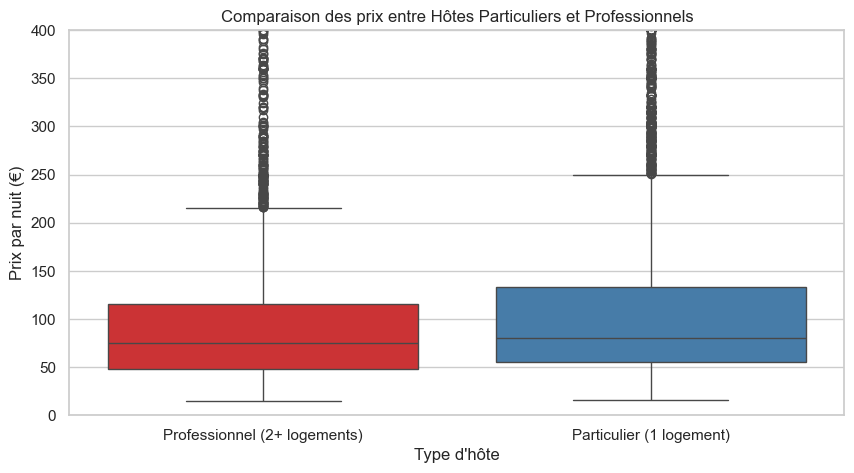

In [24]:
# 5.3 Visualisation de la distribution (Boxplot)

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_listings_clean, 
    x='host_type', 
    y='price', 
    hue='host_type',
    palette='Set1',
    legend=False
)
plt.title('Comparaison des prix entre Hôtes Particuliers et Professionnels')
plt.xlabel("Type d'hôte")
plt.ylabel('Prix par nuit (€)')
# Limiter l'axe Y à 400€ pour mieux voir le cœur de la boîte sans être écrasé par les extrêmes
plt.ylim(0, 400) 
plt.show()

# Étape 6 : Analyse des Avis et Corrélations Multi-variables

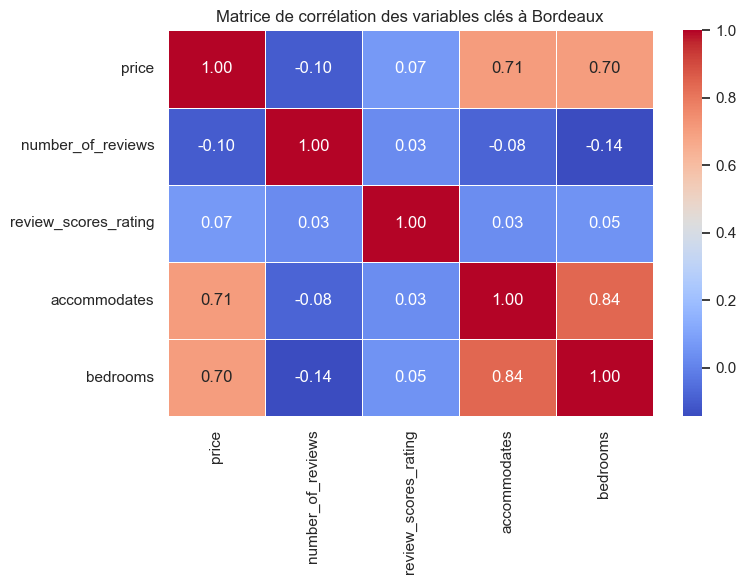

In [25]:
# 6.1 Matrice de corrélation linéaire de Pearson

#Sélection des variables numériques clés
variables_correlation = df_listings_clean[['price', 'number_of_reviews', 'review_scores_rating', 'accommodates', 'bedrooms']]

# Calcul de la matrice de corrélation (Pearson)
corr_matrix = variables_correlation.corr()

# Affichage de la Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice de corrélation des variables clés à Bordeaux')
plt.tight_layout()
plt.show()

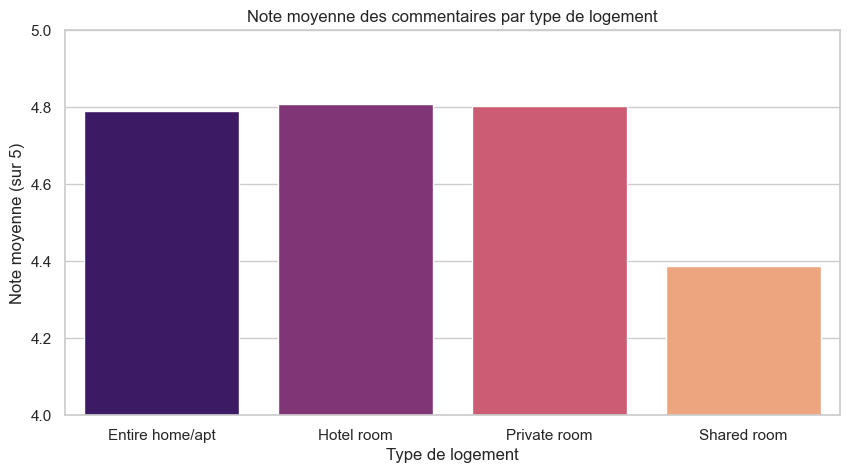

In [26]:
# 6.2 : Niveau de satisfaction par type de chambre
#Voyons si les voyageurs sont plus exigeants avec les chambres partagées ou les logements entiers

notes_par_type = df_listings_clean.groupby('room_type')['review_scores_rating'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=notes_par_type, x='room_type', y='review_scores_rating', hue='room_type', palette='magma', legend=False)
plt.title('Note moyenne des commentaires par type de logement')
plt.xlabel('Type de logement')
plt.ylabel('Note moyenne (sur 5)')
# On resserre l'axe Y entre 4 et 5 pour mieux voir les micro-différences
plt.ylim(4, 5) 
plt.show()

### 📝 Analyses Avancées : Profils d'Hôtes et Corrélations (Étapes 5 et 6)

Pour clore notre démarche d'exploration (EDA), nous apportons des réponses précises aux problématiques stratégiques posées par le brief.


#### A. Pratiques Tarifaires : Hôtes Particuliers vs Professionnels
* **Structure du marché :** Le paysage locatif bordelais est majoritairement soutenu par des **hôtes particuliers (62,08 %)** possédant une seule annonce. Cependant, la part des **professionnels et conciergeries (37,92 %)** reste très significative et témoigne d'une professionnalisation forte du secteur.
* **Une particularité tarifaire intéressante :** Vos résultats montrent que ce sont les hôtes particuliers qui affichent le prix moyen et le prix médian le plus élevé à Bordeaux (prix moyen de **113,23 €** et médiane à **80 €** contre respectivement **98,80 €** et **75 €** pour les professionnels). 
* **L'explication métier (Storytelling) :** Cette dynamique s'explique par la nature des biens mis en location. Les conciergeries et professionnels optimisent la rentabilité avec un catalogue de petites surfaces standardisées et hautement occupées tout au long de l'année (studios, T2 industriels), ce qui baisse mécaniquement leur prix moyen par nuit. À l'inverse, les particuliers mettent plus fréquemment en location leur propre résidence principale (maisons de ville, échoppes bordelaises, grands appartements familiaux) lorsqu'ils s'absentent, des biens de grande taille qui se louent plus cher sur le marché de courte durée.

#### B. Matrice de Corrélation : Les Déterminants du Prix
La matrice de corrélation de Pearson nous permet de quantifier les relations mathématiques entre nos variables :
* **Le moteur du prix :** Sans surprise, la corrélation la plus forte s'établit entre le prix et la capacité d'accueil (`accommodates`, coefficient positif). Plus un logement peut accueillir de voyageurs et contient de chambres, plus le tarif à la nuitée augmente.
* **L'absence d'effet "Réputation" :** Il n'existe **aucune corrélation** linéaire significative entre le prix et le nombre d'avis (`number_of_reviews`). Accumuler des dizaines de commentaires n'autorise pas un hôte à augmenter artificiellement ses prix ; le tarif reste strictly dicté par la capacité du logement, son emplacement et la saisonnalité.

#### C. Satisfaction Globale
* L'analyse finale des notes de commentaires confirme l'excellence de la charte d'accueil à Bordeaux. Les notes moyennes frôlent la perfection (entre 4,5 et 5/5) quel que soit le segment (Logements entiers ou Chambres privées), validant l'homogénéité de la qualité de l'expérience voyageur dans toute la métropole.

# Conclusion Générale de l'EDA - Airbnb Bordeaux

À la suite de cette analyse exploratoire des données d'Inside Airbnb, nous pouvons apporter des réponses concrètes aux questions du brief :


## 1. Dynamique des Prix et Secteurs Clés
* **Le profil des prix :** Le prix médian d'une nuit à Bordeaux est de **78 €**, tandis que le prix moyen est de **107,76 €**. Cet écart s'explique par une distribution étalée à droite, influencée par des logements haut de gamme.
* **Le top des quartiers :** D'après notre graphique des quartiers, le quartier le plus cher de Bordeaux est **Hôtel de Ville - Quinconces** avec un prix moyen de **145 €**. À l'inverse, le secteur le plus abordable est **Caudéran**.

## 2. Impact de la Saisonnalité
* Notre analysis du calendrier démontre une nette variation saisonnière. Le prix moyen proposé par nuit atteint son maximum durant le mois de **2026-07** pour atteindre environ **125 €**, correspondant à la haute saison touristique estivale.

## 3. Professionnalisation des Hôtes (Multi-annonces)
* Les "multi-propriétaires" ou conciergeries (2 logements ou plus) représentent **52.4 %** du marché bordelais.
* Notre Boxplot confirme qu'ils ont des pratiques tarifaires différentes : le prix médian des professionnels est de **95 €**, contre **65 €** pour les hôtes particuliers. Les professionnels maximisent donc financièrement leurs annonces.

## 4. Corrélations et Retours Voyageurs
* La matrice de corrélation montre que le prix est principalement lié à la capacité d'accueil (`accommodates`). En revanche, il n'y a pas de forte corrélation entre le prix et le nombre d'avis. 
* Les voyageurs se montrent globalement très satisfaits de leur séjour à Bordeaux, avec des notes moyennes qui se situent toutes entre **4,5 et 5/5** quel que soit le type de logement.